# 5. Historical Word Embedding Models

Train Word2Vec models on period-specific corpora (EEBO-TCP, ECCO-TCP, COHA)
and compute how abstract/concrete word meanings shift across centuries.

In [2]:
from abstraction.models import (
    get_model_paths, load_model, gen_skipgrams_corpus,
    gen_model, gen_vecnorms
)
from abstraction.norms import get_vecnorms, get_allnorms, corr_norms
from abstraction.config import PATH_DATA
import pandas as pd
import os
import json

## Model sizes

In [3]:
path_models = '/Volumes/diderot/DH/data/models_century5'
path_words = os.path.join(PATH_DATA, 'fields', 'oed_words.json')
with open(path_words, 'r') as f:
    all_words = {x.lower().strip() for x in json.load(f)}

o = []
for root, dirs, files in sorted(os.walk(path_models)):
    if 'vocab.txt' in files:
        vocab_path = os.path.join(root, 'vocab.txt')
        df = pd.read_csv(vocab_path, sep=' ', header=None).rename(columns={0: 'word', 1: 'count'})
        df['word_recog'] = df['word'].isin(all_words)

        num_types = len(df)
        num_tokens = df['count'].sum()
        num_types_recog = df['word_recog'].sum()
        num_tokens_recog = df.loc[df['word_recog'], 'count'].sum()

        odx = {
            'corpus': root.split('/')[-3],
            'period': root.split('/')[-2],
            'num_tokens': num_tokens,
            'num_types': num_types,
            'num_tokens_recog': num_tokens_recog,
            'num_types_recog': num_types_recog,
            'perc_tokens_recog': num_tokens_recog / num_tokens,
            'perc_types_recog': num_types_recog / num_types,
        }
        o.append(odx)

odf = pd.DataFrame(o).drop_duplicates(['corpus', 'period'])

print(f'Total tokens: {odf["num_tokens"].sum():,}')
print(f'Total types: {odf["num_types"].sum():,}')

# Add one total row per period
period_totals = (
    odf.groupby('period', as_index=False)
    .agg(
        num_tokens=('num_tokens', 'sum'),
        num_types=('num_types', 'sum'),
        num_tokens_recog=('num_tokens_recog', 'sum'),
        num_types_recog=('num_types_recog', 'sum'),
    )
)
totalname='Total'
period_totals['corpus'] = totalname
period_totals['perc_tokens_recog'] = period_totals['num_tokens_recog'] / period_totals['num_tokens']
period_totals['perc_types_recog'] = period_totals['num_types_recog'] / period_totals['num_types']

odf = pd.concat([odf, period_totals], ignore_index=True)
odf['_is_total'] = odf['corpus'].eq(totalname)
odf = odf.sort_values(['period', '_is_total', 'num_tokens'], ascending=[True, True, False])
odf = odf.drop(columns=['_is_total', 'num_tokens_recog', 'num_types_recog']).set_index(['period', 'corpus'])

odf['num_tokens'] = odf['num_tokens'].apply(lambda x: f'{x:,}')
odf['num_types'] = odf['num_types'].apply(lambda x: f'{x:,}')
odf['perc_tokens_recog'] = odf['perc_tokens_recog'].apply(lambda x: f'{x:.1%}')
odf['perc_types_recog'] = odf['perc_types_recog'].apply(lambda x: f'{x:.1%}')
odf

Total tokens: 8,864,743,378
Total types: 4,260,668


num_tokens  num_types perc_tokens_recog  \
period    corpus                                                  
1500-1600 eebo_tcp      67,127,330     91,525             90.2%   
          Total         67,127,330     91,525             90.2%   
1600-1700 eebo_tcp     535,091,733    253,112             90.7%   
          blbooks       15,208,500     46,388             85.2%   
          Total        550,300,233    299,500             90.6%   
1700-1800 ecco       2,577,735,685  1,758,932             85.8%   
          bpo          154,263,602     78,891             90.1%   
          evans_tcp     88,047,968     54,644             91.0%   
          ecco_tcp      65,318,177     73,935             90.7%   
          blbooks       35,102,745     78,918             84.2%   
          Total      2,920,468,177  2,045,320             86.3%   
1800-1900 blbooks    2,962,302,329    986,246             88.6%   
          bpo        1,197,984,538    181,518             90.5%   
          coha         121,394,112     84,396             91.6%   
          Total      4,281,680,979  1,252,160             89.2%   
1900-2000 bpo          332,412,238    120,647             89.6%   
          coha         226,348,381    148,177             89.6%   
          coca         187,848,974    129,225             88.2%   
          Total        746,609,593    398,049             89.2%   
2000-2100 coca         298,557,066    174,114             87.5%   
          Total        298,557,066    174,114             87.5%   

                    perc_types_recog  
period    corpus                      
1500-1600 eebo_tcp             28.8%  
          Total                28.8%  
1600-1700 eebo_tcp             19.9%  
          blbooks              37.4%  
          Total                22.6%  
1700-1800 ecco                  4.5%  
          bpo                  48.1%  
          evans_tcp            50.1%  
          ecco_tcp             40.8%  
          blbooks              34.3%  
          Total                 9.8%  
1800-1900 blbooks               9.7%  
          bpo                  38.8%  
          coha                 44.5%  
          Total                16.2%  
1900-2000 bpo                  44.9%  
          coha                 34.0%  
          coca                 36.0%  
          Total                37.9%  
2000-2100 coca                 29.5%  
          Total                29.5%

In [4]:
odf.query(f'corpus=="{totalname}"')

,,num_tokens,num_types,perc_tokens_recog,perc_types_recog
period,corpus,,,,
1500-1600,Total,"67,127,330","91,525",90.2%,28.8%
1600-1700,Total,"550,300,233","299,500",90.6%,22.6%
1700-1800,Total,"2,920,468,177","2,045,320",86.3%,9.8%
1800-1900,Total,"4,281,680,979","1,252,160",89.2%,16.2%
1900-2000,Total,"746,609,593","398,049",89.2%,37.9%
2000-2100,Total,"298,557,066","174,114",87.5%,29.5%


## Inspect available models

In [5]:
paths = get_model_paths()
if paths:
    df_paths = pd.DataFrame(paths)
    print(f'{len(df_paths)} model files found')
    df_paths.groupby(['corpus', 'period_start', 'period_end']).size().reset_index(name='runs')
else:
    print('No models found in data/models/. Generate skipgrams first.')

32 model files found


## Load a model and explore word neighborhoods

In [6]:
if paths:
    model = load_model(paths[0]['path'])
    kv = model.wv if hasattr(model, 'wv') else model
    print(f'Vocabulary size: {len(kv)}')
    
    for word in ['virtue', 'justice', 'rock', 'face']:
        if word in kv:
            neighbors = kv.most_similar(word, topn=5)
            print(f'\n{word}: {[(w, round(s, 3)) for w, s in neighbors]}')

Vocabulary size: 46388

virtue: [('vertue', 0.865), ("vertue's", 0.741), ('unconquerable', 0.735), ('magnanimity', 0.724), ("flatt'ry", 0.719)]

justice: [('just', 0.786), ('cause', 0.74), ('punish', 0.723), ('reason', 0.686), ('treason', 0.685)]

rock: [('rocks', 0.8), ('rocky', 0.724), ('billow', 0.7), ('floating', 0.694), ('craggy', 0.677)]

face: [('countenance', 0.715), ('visage', 0.715), ('mein', 0.712), ('shape', 0.694), ('palenefs', 0.685)]


In [24]:
from abstraction.norms import get_origcontrasts
from abstraction.models import get_fieldvecs_in_model, _gen_vecnorms_for_model
targets = ['virtue', 'justice', 'rock', 'face','fine','broad','human','interest','culture']

o = []
for path in sorted(paths, key=lambda x: x['period_start']):
    if path['run']!='run_01': continue
    print(f'{path["corpus"]} ({path["period_start"]}-{path["period_end"]})')
    pdf=pd.DataFrame(_gen_vecnorms_for_model(path,words=targets))
    pdf=pdf[pdf.word.isin(targets)].pivot(index='word',columns='source',values='score').sort_values('Abs-Conc.Median')
    o.append(pdf.reset_index().assign(period_start=path['period_start'], corpus=path['corpus']))
    display(pdf)
    print()

eebo_tcp (1500-1600)


source,Abs-Conc.LSN-Hapt,Abs-Conc.LSN-Imag,Abs-Conc.MRC-Conc,Abs-Conc.MRC-Imag,Abs-Conc.MT-Conc,Abs-Conc.Median,Abs-Conc.PAV-Conc,Abs-Conc.PAV-Imag
word,,,,,,,,
broad,0.510092,0.485028,0.525484,0.567976,0.565482,0.514910,0.517462,0.560427
culture,0.508744,0.597852,0.603541,0.650086,0.649516,0.578186,0.603697,0.657989
fine,0.654542,0.692033,0.695895,0.795563,0.697934,0.684993,0.683024,0.785149
rock,0.742084,0.771130,0.718433,0.698533,0.775133,0.758427,0.715257,0.679512
face,0.810015,0.753847,0.793448,0.726229,0.823417,0.787763,0.816402,0.772747
virtue,1.075911,1.124013,1.204270,1.197290,1.169293,1.145328,1.236941,1.238750
interest,1.179035,1.171150,1.214149,1.286911,1.148785,1.189008,1.199343,1.304307
justice,1.220303,1.156071,1.253516,1.244990,1.211297,1.212385,1.256915,1.245507
human,1.134445,1.168379,1.254134,1.245465,1.268692,1.228223,1.250198,1.263947



blbooks (1600-1700)


source,Abs-Conc.LSN-Hapt,Abs-Conc.LSN-Imag,Abs-Conc.MRC-Conc,Abs-Conc.MRC-Imag,Abs-Conc.MT-Conc,Abs-Conc.Median,Abs-Conc.PAV-Conc,Abs-Conc.PAV-Imag
word,,,,,,,,
broad,0.637401,0.568335,0.626153,0.635031,0.676623,0.627846,0.604782,0.614050
rock,0.739006,0.756642,0.725640,0.685854,0.781605,0.741100,0.693851,0.635287
fine,0.863553,0.854904,0.857700,0.914022,0.884955,0.872196,0.864995,0.933846
face,0.906495,0.820782,0.918487,0.846336,0.932568,0.897128,0.986640,0.926401
justice,1.267743,1.249692,1.287204,1.250795,1.249117,1.253994,1.286815,1.240822
virtue,1.314322,1.272835,1.368818,1.293043,1.386690,1.336523,1.382597,1.298168
human,1.299734,1.317872,1.349323,1.358681,1.412808,1.375130,1.320990,1.305770
interest,1.383961,1.391286,1.462341,1.449079,1.418564,1.421139,1.454473,1.381405



eebo_tcp (1600-1700)


...

source,Abs-Conc.LSN-Hapt,Abs-Conc.LSN-Imag,Abs-Conc.MRC-Conc,Abs-Conc.MRC-Imag,Abs-Conc.MT-Conc,Abs-Conc.Median,Abs-Conc.PAV-Conc,Abs-Conc.PAV-Imag
word,,,,,,,,
rock,0.792545,0.782673,0.732918,0.727300,0.759271,0.766284,0.741444,0.719131
fine,0.844344,0.877051,0.943478,0.987975,0.954415,0.909170,0.927503,0.957621
face,1.105290,1.118086,1.235406,1.226951,1.238511,1.190267,1.227959,1.217980
broad,1.128213,1.122037,1.211001,1.278355,1.237193,1.195356,1.170813,1.230777
culture,1.299368,1.274649,1.313664,1.293877,1.316990,1.318376,1.325025,1.351076
interest,1.316516,1.302741,1.384040,1.381135,1.351941,1.349991,1.383227,1.409404
human,1.241715,1.339776,1.362345,1.359924,1.379625,1.356014,1.357080,1.387700
justice,1.380609,1.310590,1.377554,1.363067,1.333149,1.365080,1.400510,1.409617
virtue,1.301691,1.306965,1.451129,1.424914,1.413478,1.385277,1.474661,1.477384



coha (1900-2000)


source,Abs-Conc.LSN-Hapt,Abs-Conc.LSN-Imag,Abs-Conc.MRC-Conc,Abs-Conc.MRC-Imag,Abs-Conc.MT-Conc,Abs-Conc.Median,Abs-Conc.PAV-Conc,Abs-Conc.PAV-Imag
word,,,,,,,,
rock,0.751619,0.751358,0.733056,0.732964,0.751490,0.741978,0.740846,0.741626
fine,0.734761,0.799793,0.835370,0.867998,0.886494,0.820794,0.826535,0.844724
face,0.935710,0.958309,1.048994,1.036381,1.082290,1.018475,1.054712,1.033668
broad,0.966071,0.938840,1.054345,1.108754,1.103706,1.035367,1.026837,1.065030
culture,1.246527,1.219022,1.286894,1.276081,1.298066,1.270557,1.306757,1.333869
human,1.231303,1.332484,1.321281,1.319544,1.358186,1.330584,1.333497,1.360637
interest,1.301061,1.303997,1.373871,1.377247,1.331339,1.332750,1.390842,1.409318
justice,1.365853,1.306863,1.314006,1.321649,1.302669,1.339483,1.336402,1.360048
virtue,1.360599,1.379088,1.495667,1.480382,1.449328,1.434403,1.524781,1.534420



coca (2000-2100)


source,Abs-Conc.LSN-Hapt,Abs-Conc.LSN-Imag,Abs-Conc.MRC-Conc,Abs-Conc.MRC-Imag,Abs-Conc.MT-Conc,Abs-Conc.Median,Abs-Conc.PAV-Conc,Abs-Conc.PAV-Imag
word,,,,,,,,
rock,0.808001,0.736561,0.732899,0.719515,0.757503,0.756598,0.744320,0.715372
fine,0.911471,0.951973,0.997710,1.053832,1.015315,0.979406,0.987992,1.031565
broad,1.108905,1.123659,1.191345,1.272808,1.226403,1.185916,1.165270,1.244332
face,1.126501,1.134763,1.256733,1.256544,1.252299,1.203719,1.246193,1.242047
human,1.161016,1.283293,1.242032,1.264702,1.253064,1.253234,1.224013,1.263328
culture,1.214696,1.229357,1.251676,1.254583,1.253338,1.253897,1.265378,1.290058
interest,1.308074,1.308452,1.393053,1.388453,1.333326,1.340847,1.403271,1.424224
justice,1.417991,1.325946,1.389009,1.381006,1.355909,1.390606,1.426565,1.424272
virtue,1.362266,1.355707,1.498817,1.458625,1.464729,1.442265,1.529041,1.517322


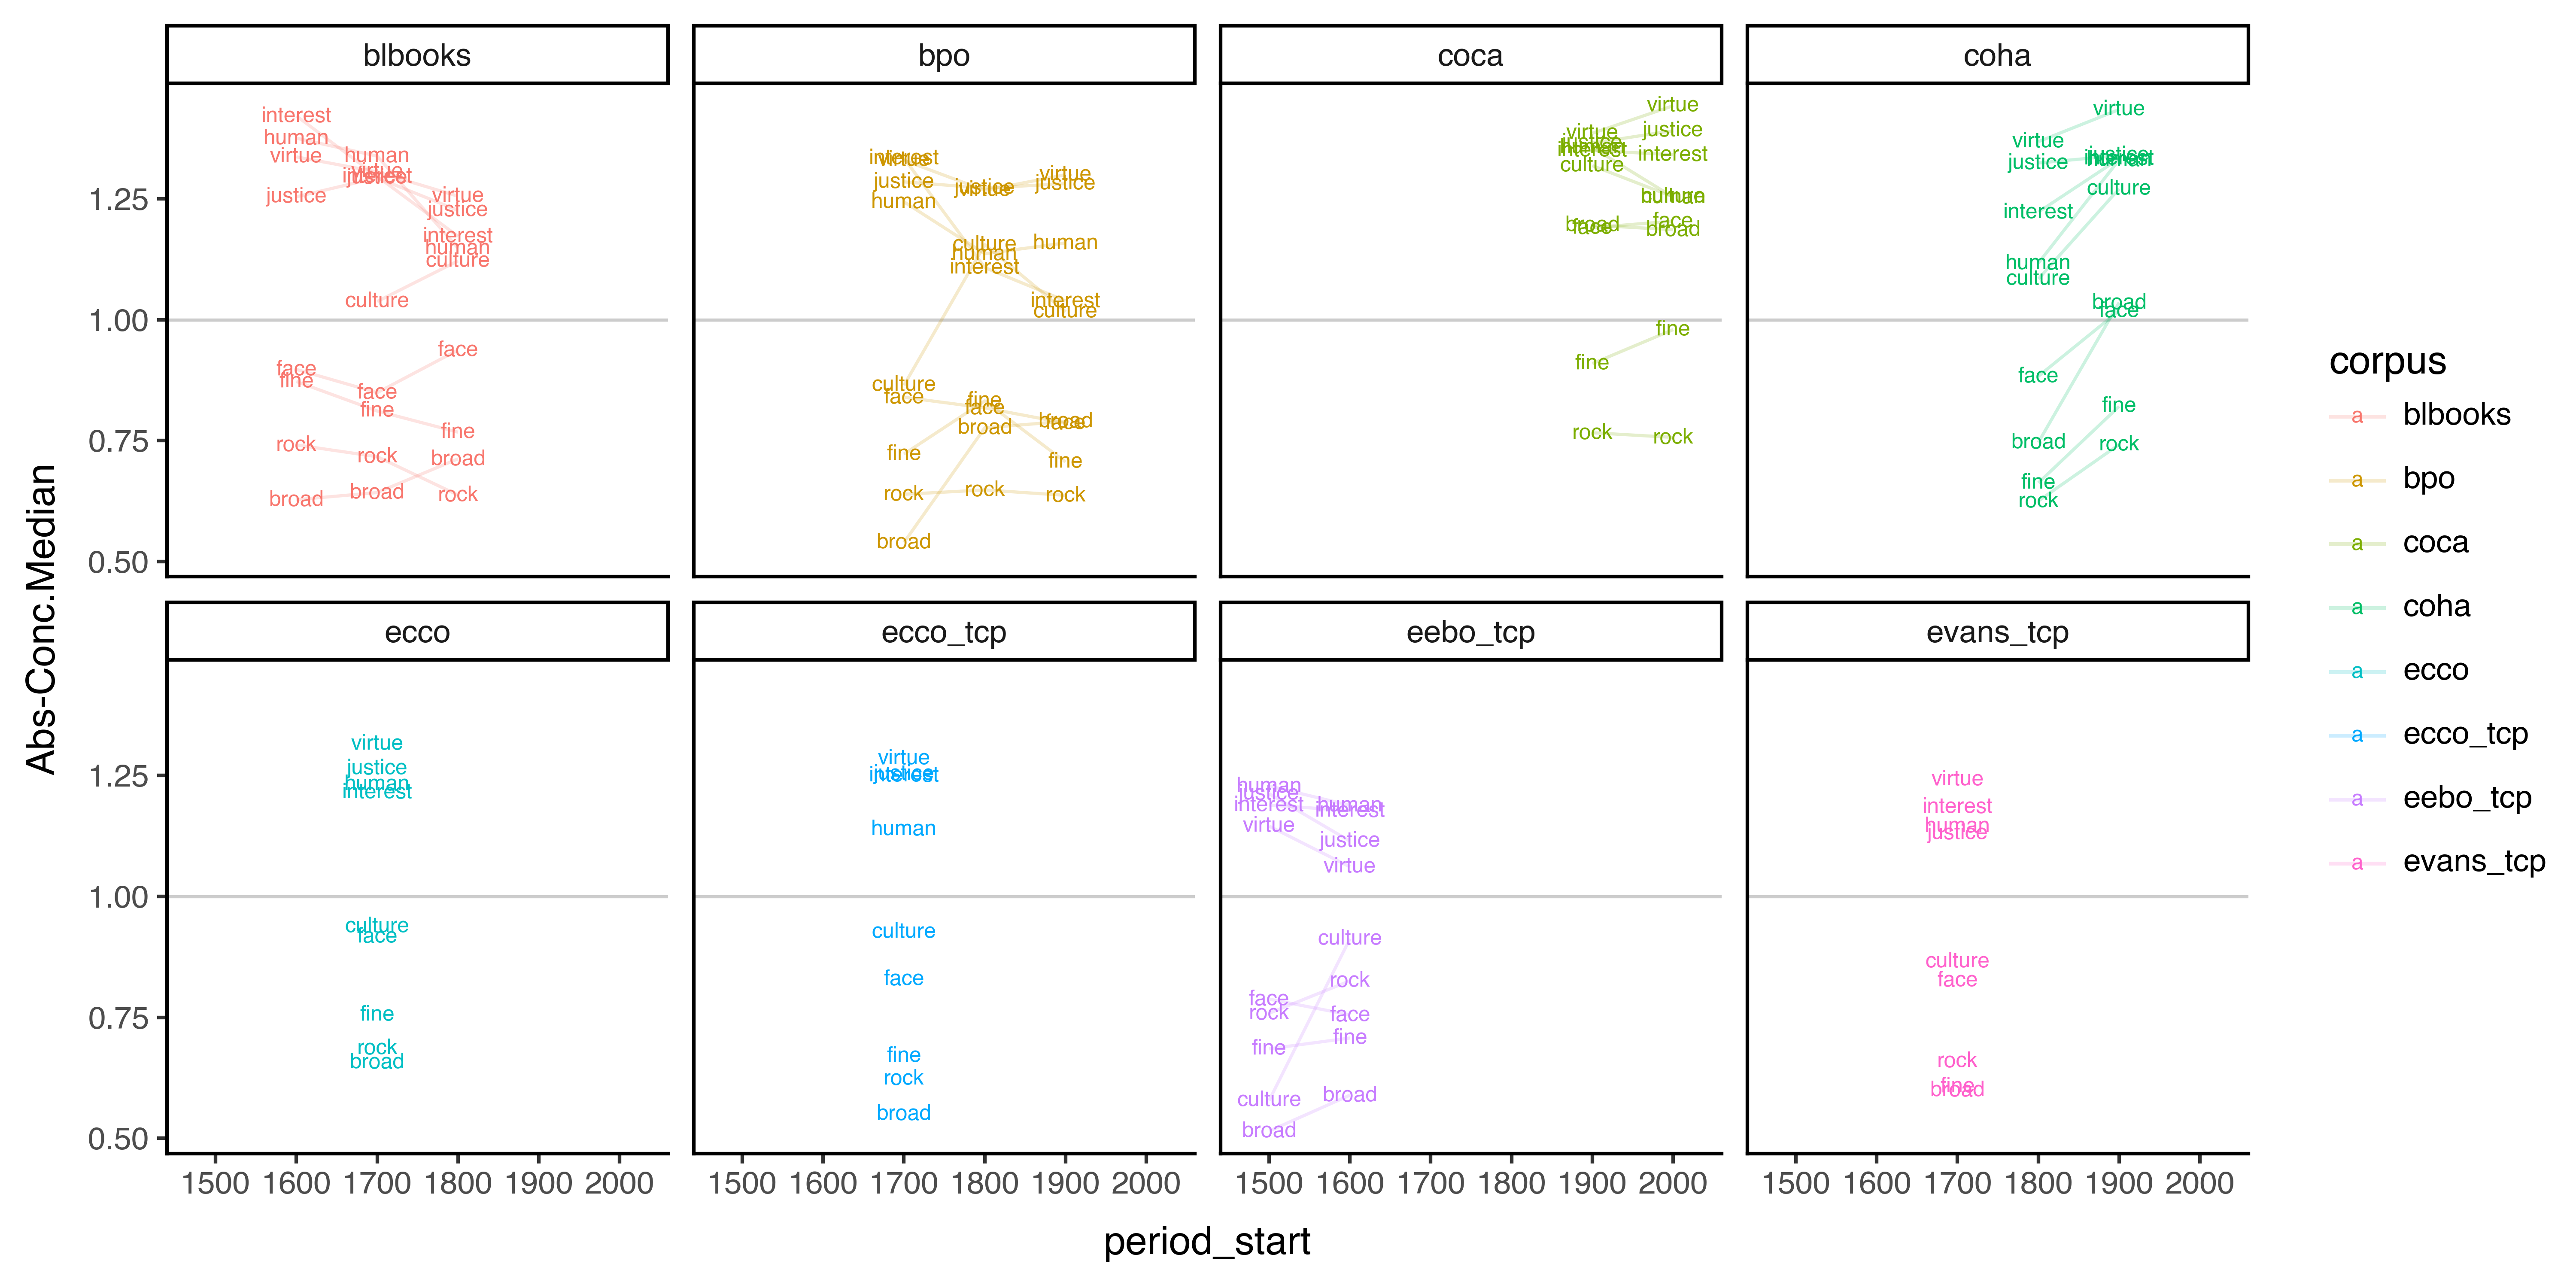

In [34]:
import plotnine as p9
import warnings
warnings.filterwarnings('ignore')
figdf = pd.concat(o)
fig  = (
    p9.ggplot(figdf, p9.aes(x='period_start', y='Abs-Conc.Median',color='corpus',label='word',group='word'))
    + p9.geom_hline(yintercept=1.0, color='black', alpha=.2)
    + p9.geom_line(alpha=.2)
    + p9.geom_text(size=6)
    + p9.theme_classic()
    + p9.theme(figure_size=(10, 5), dpi=300)
    + p9.facet_wrap('corpus', ncol=4)
)
fig

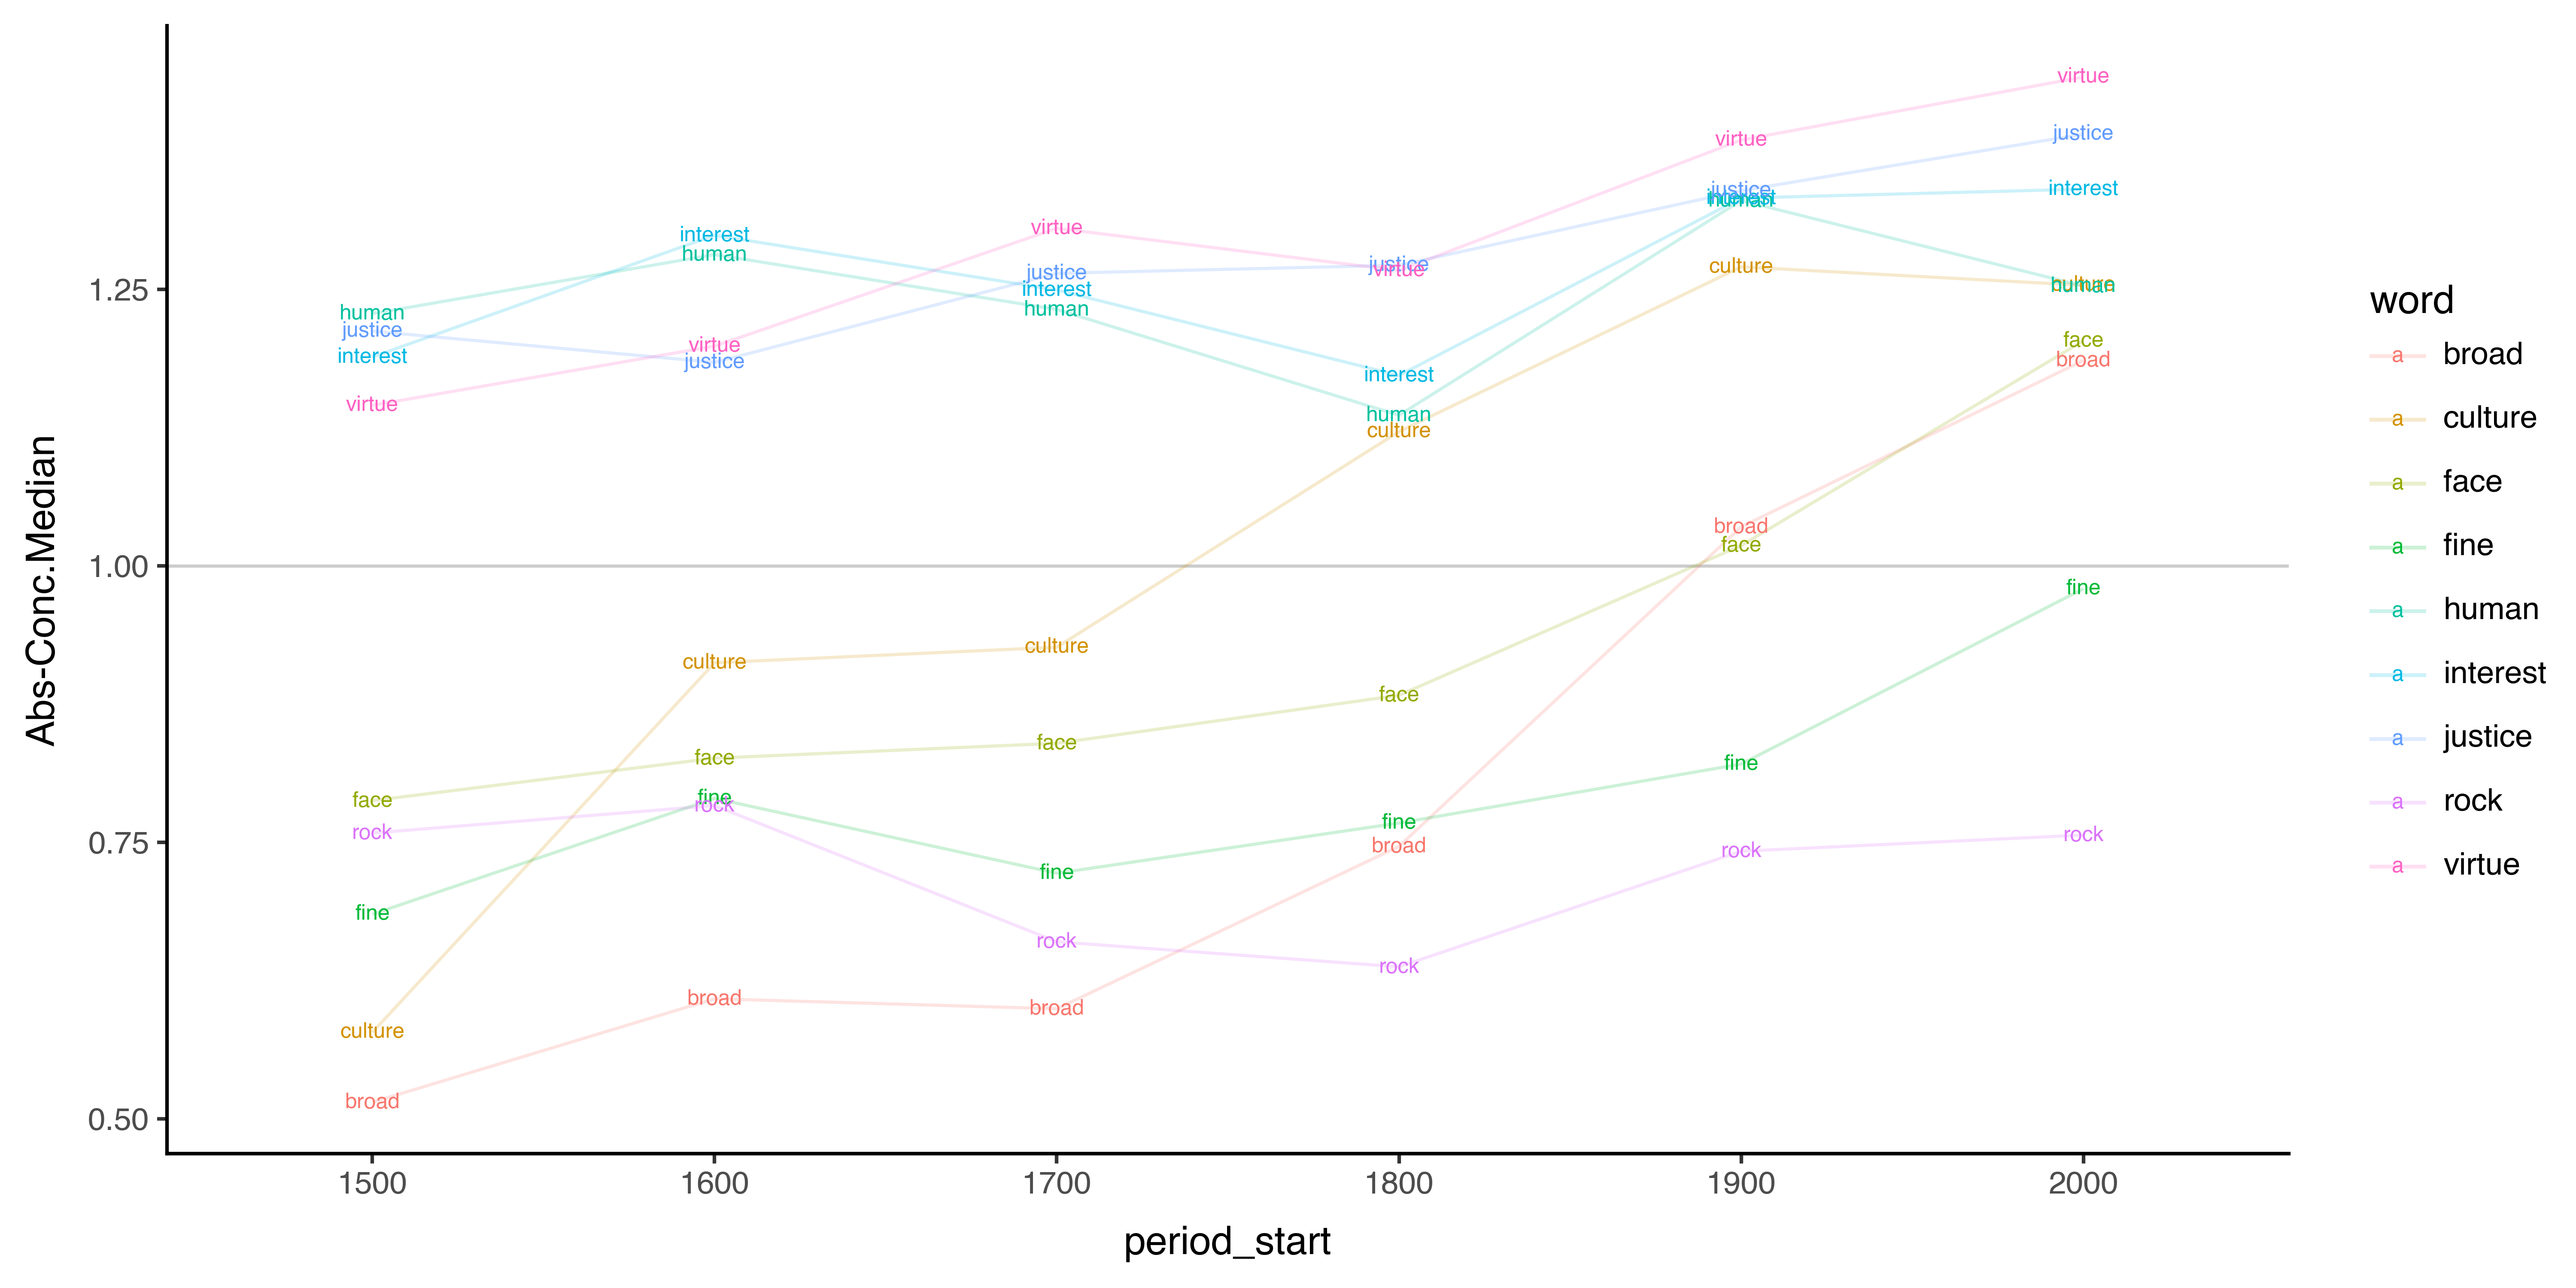

In [38]:
import plotnine as p9
import warnings
warnings.filterwarnings('ignore')
figdf = pd.concat(o).groupby(['word','period_start']).median(numeric_only=True).reset_index()
fig  = (
    p9.ggplot(figdf, p9.aes(x='period_start', y='Abs-Conc.Median',color='word',label='word',group='word'))
    + p9.geom_hline(yintercept=1.0, color='black', alpha=.2)
    + p9.geom_line(alpha=.2)
    + p9.geom_text(size=6)
    + p9.theme_classic()
    + p9.theme(figure_size=(10, 5), dpi=300)
)
fig

## Vector-based norms

These are concreteness scores derived from historical models rather than modern surveys.
They show how abstract/concrete a word was *in its historical usage context*.

In [72]:
try:
    vecnorms = get_vecnorms()
    print(f'{len(vecnorms)} words, {len(vecnorms.columns)} period-source columns')
    vecnorms.head()
except FileNotFoundError:
    print('Vector norms not yet generated. Run gen_vecnorms() first.')

KeyboardInterrupt: 

## Correlation: empirical vs. historical norms

In [ ]:
try:
    allnorms = get_allnorms()
    corr_df = corr_norms(allnorms)
    print(f'Min r = {corr_df["value"].min():.3f}, Median r = {corr_df["value"].median():.3f}, Max r = {corr_df["value"].max():.3f}')
    corr_df.head(10)
except FileNotFoundError:
    print('All-norms file not found. Generate empirical and vector norms first.')

## Pipeline: generating from scratch

The full pipeline for creating models and vector norms. Each step is expensive and
writes results to disk, so they only need to run once.

In [ ]:
# Step 1: Generate skipgrams from corpus text files
# gen_skipgrams_corpus('eebo_tcp', min_year=1500, max_year=1700, num_proc=4)
# gen_skipgrams_corpus('ecco_tcp', min_year=1700, max_year=1800, num_proc=4)
# gen_skipgrams_corpus('coha', min_year=1800, max_year=2000, num_proc=4)

In [ ]:
# Step 2: Train Word2Vec models (multiple runs per period)
# from abstraction.models import gen_models_corpus
# gen_models_corpus('eebo_tcp', num_runs=10, num_proc=4)
# gen_models_corpus('ecco_tcp', num_runs=10, num_proc=4)
# gen_models_corpus('coha', num_runs=10, num_proc=4)

In [ ]:
# Step 3: Compute vector-based norms from trained models
# gen_vecnorms()